Ready! Here is our map:


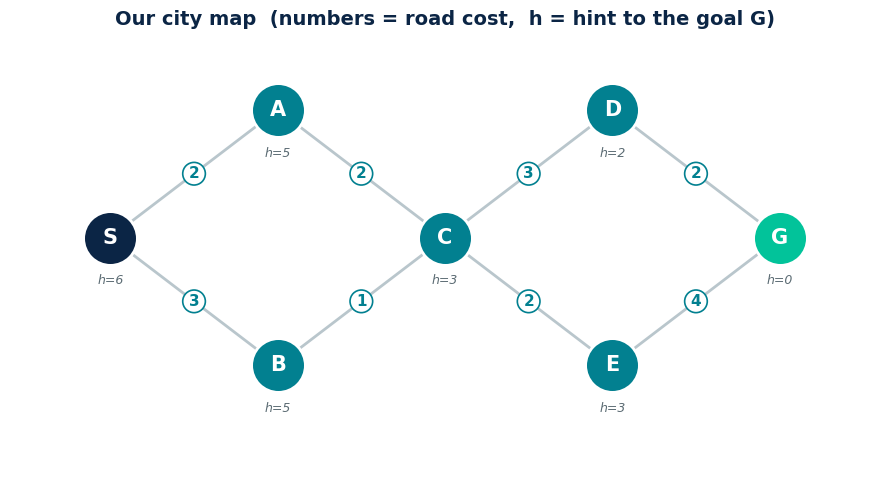

In [1]:
# STEP 1 - just run this cell (do not change anything). Press Shift+Enter.
import heapq, copy
from collections import deque
import matplotlib.pyplot as plt

# Our little map. Each city lists its neighbours and the road cost (travel time).
GRAPH = {
    'S': {'A': 2, 'B': 3},
    'A': {'S': 2, 'C': 2},
    'B': {'S': 3, 'C': 1},
    'C': {'A': 2, 'B': 1, 'D': 3, 'E': 2},
    'D': {'C': 3, 'G': 2},
    'E': {'C': 2, 'G': 4},
    'G': {'D': 2, 'E': 4},
}
# The "hint": straight-line guess of how far each city is from the goal G.
HEURISTIC = {'S': 6, 'A': 5, 'B': 5, 'C': 3, 'D': 2, 'E': 3, 'G': 0}

def _rebuild(came, goal):
    p, c = [], goal
    while c is not None: p.append(c); c = came.get(c)
    return p[::-1]

def bfs(graph, start, goal):
    fr, came = deque([start]), {start: None}
    while fr:
        n = fr.popleft()
        if n == goal: break
        for nb in graph[n]:
            if nb not in came: came[nb] = n; fr.append(nb)
    return _rebuild(came, goal)

def astar(graph, start, goal, h):
    fr, came, g = [(h[start], 0, start)], {start: None}, {start: 0}
    while fr:
        _, gg, n = heapq.heappop(fr)
        if n == goal: break
        for nb, w in graph[n].items():
            ng = g[n] + w
            if nb not in g or ng < g[nb]:
                g[nb] = ng; came[nb] = n
                heapq.heappush(fr, (ng + h[nb], ng, nb))
    path = _rebuild(came, goal)
    return path, g.get(goal)

def draw_map(path=None, title="Our city map"):
    pos = {'S':(0,1),'A':(1,2),'B':(1,0),'C':(2,1),'D':(3,2),'E':(3,0),'G':(4,1)}
    fig, ax = plt.subplots(figsize=(9,5)); seen=set()
    for a in GRAPH:
        for b,w in GRAPH[a].items():
            if (b,a) in seen: continue
            seen.add((a,b)); x1,y1=pos[a]; x2,y2=pos[b]
            hot = bool(path) and a in path and b in path and abs(path.index(a)-path.index(b))==1
            ax.plot([x1,x2],[y1,y2], color=('#02C39A' if hot else '#B9C6CC'), lw=(5 if hot else 2), zorder=1)
            ax.text((x1+x2)/2,(y1+y2)/2,str(w),fontsize=11,ha='center',va='center',color='#028090',
                    fontweight='bold',bbox=dict(boxstyle='circle,pad=0.25',fc='white',ec='#028090',lw=1.2),zorder=3)
    for n,(x,y) in pos.items():
        fc = '#0B2545' if n=='S' else ('#02C39A' if n=='G' else '#028090')
        ax.scatter([x],[y],s=1500,c=fc,zorder=4,edgecolors='white',linewidths=2)
        ax.text(x,y,n,fontsize=15,ha='center',va='center',color='white',fontweight='bold',zorder=5)
        ax.text(x,y-0.34,f"h={HEURISTIC[n]}",fontsize=9,ha='center',va='center',color='#5b6b73',style='italic',zorder=5)
    ax.set_title(title,fontsize=14,fontweight='bold',color='#0B2545')
    ax.axis('off'); ax.set_xlim(-0.6,4.6); ax.set_ylim(-0.9,2.6); plt.tight_layout(); plt.show()

print("Ready! Here is our map:")
draw_map(title="Our city map  (numbers = road cost,  h = hint to the goal G)")

A* route from B to G: B -> C -> D -> G  | cost = 6


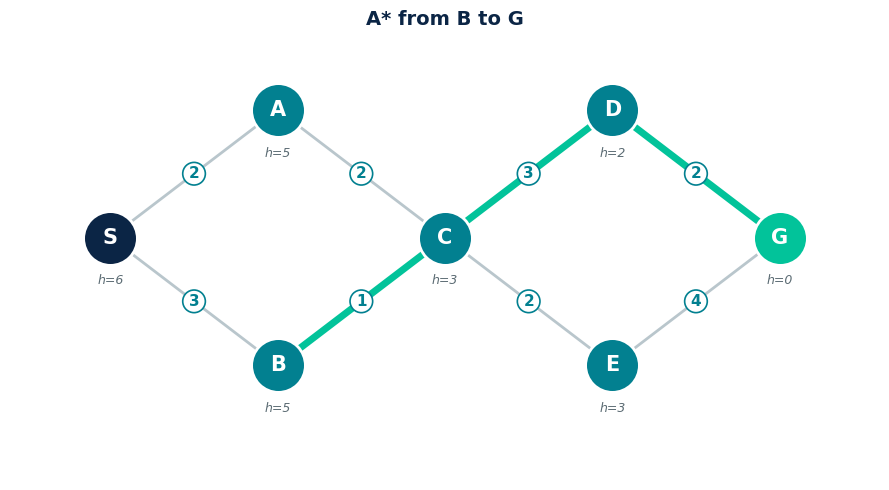

In [2]:


# TASK 1 - Start somewhere else.
# Change the city in quotes below, then press Shift+Enter. Try 'B', then 'A'.
start_here = 'B'          # <-- edit me

route, cost = astar(GRAPH, start_here, 'G', HEURISTIC)
print(f"A* route from {start_here} to G:", " -> ".join(route), " | cost =", cost)
draw_map(route, f"A* from {start_here} to G")

Task 1 - Start from a different city

A* route from B to G: B -> C -> D -> G  | cost = 6


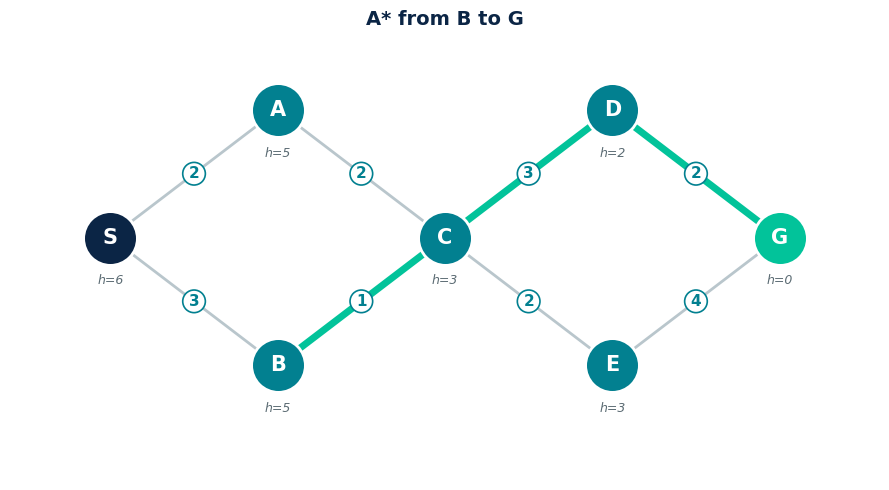

In [3]:
# TASK 1 - Start somewhere else.
# Change the city in quotes below, then press Shift+Enter. Try 'B', then 'A'.
start_here = 'B'          # <-- edit me

route, cost = astar(GRAPH, start_here, 'G', HEURISTIC)
print(f"A* route from {start_here} to G:", " -> ".join(route), " | cost =", cost)
draw_map(route, f"A* from {start_here} to G")


Task 2 - Block a road
Make the road S-A slow and see whether A* avoids it and takes the lower path instead.

With road S-A = 9, A* route: S -> B -> C -> D -> G  | cost = 9


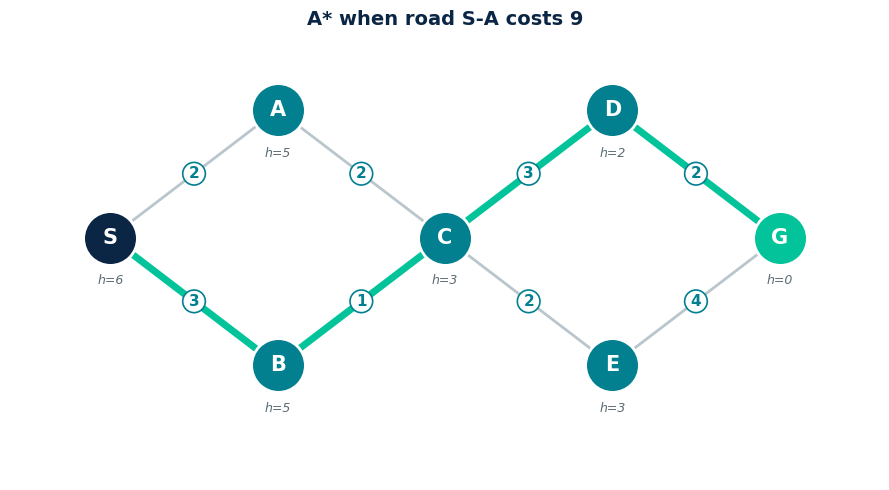

In [4]:
# TASK 2 - Block a road and see if A* goes around it.
# Right now the road S-A costs 2. Make it slow (try 9) and re-run.
new_cost = 9              # <-- edit me (try 9, then try 2 again)

my_map = copy.deepcopy(GRAPH)      # a copy, so the original map stays safe
my_map['S']['A'] = new_cost
my_map['A']['S'] = new_cost

route, cost = astar(my_map, 'S', 'G', HEURISTIC)
print(f"With road S-A = {new_cost}, A* route:", " -> ".join(route), " | cost =", cost)
draw_map(route, f"A* when road S-A costs {new_cost}")